# Car Price Prediction using Ridge Regression

## Objective
To build a regression model to predict car prices based on available features and evaluate different algorithms to select the most stable model.


## Import Libraries

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split,GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [4]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

## Load Datasets

In [6]:
df = pd.read_csv(r'quikr_car.csv')
df.head()

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,"80,000","45,000 kms",Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,"4,25,000",40 kms,Diesel
2,Maruti Suzuki Alto 800 Vxi,Maruti,2018,Ask For Price,"22,000 kms",Petrol
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,"3,25,000","28,000 kms",Petrol
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,"5,75,000","36,000 kms",Diesel


## Basic Info

In [8]:
df.shape

(892, 6)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 892 entries, 0 to 891
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        892 non-null    object
 1   company     892 non-null    object
 2   year        892 non-null    object
 3   Price       892 non-null    object
 4   kms_driven  840 non-null    object
 5   fuel_type   837 non-null    object
dtypes: object(6)
memory usage: 41.9+ KB


In [10]:
df.isnull().sum()

name           0
company        0
year           0
Price          0
kms_driven    52
fuel_type     55
dtype: int64

## Data Cleaning

In [12]:
df = df.drop('name', axis = 1)

In [13]:
df['kms_driven'] = df['kms_driven'].fillna('45,000 kms')

In [14]:
df = df[df['kms_driven'] != 'Petrol'].copy()

In [15]:
df['total_drived'] = df['kms_driven'].apply(lambda x : int(x.split(' ')[0].replace(',','')))

In [16]:
df['fuel_type'].value_counts()

fuel_type
Petrol    440
Diesel    395
LPG         2
Name: count, dtype: int64

In [17]:
df['fuel_type'] = df['fuel_type'].fillna('Petrol')

In [18]:
df = df.drop('kms_driven', axis = 1)

In [19]:
df.head()

,company,year,Price,fuel_type,total_drived
0,Hyundai,2007,"80,000",Petrol,45000
1,Mahindra,2006,"4,25,000",Diesel,40
2,Maruti,2018,Ask For Price,Petrol,22000
3,Hyundai,2014,"3,25,000",Petrol,28000
4,Ford,2014,"5,75,000",Diesel,36000


In [20]:
df.shape

(890, 5)

In [21]:
df = df[df['year'].str.isnumeric()]

df['year'] = df['year'].astype('int')

In [22]:
df.head()

,company,year,Price,fuel_type,total_drived
0,Hyundai,2007,"80,000",Petrol,45000
1,Mahindra,2006,"4,25,000",Diesel,40
2,Maruti,2018,Ask For Price,Petrol,22000
3,Hyundai,2014,"3,25,000",Petrol,28000
4,Ford,2014,"5,75,000",Diesel,36000


In [23]:
df = df.drop_duplicates()

In [24]:
df.head()

,company,year,Price,fuel_type,total_drived
0,Hyundai,2007,"80,000",Petrol,45000
1,Mahindra,2006,"4,25,000",Diesel,40
2,Maruti,2018,Ask For Price,Petrol,22000
3,Hyundai,2014,"3,25,000",Petrol,28000
4,Ford,2014,"5,75,000",Diesel,36000


In [25]:
df.shape

(739, 5)

In [26]:
df = df.reset_index(drop=True)

In [27]:
df = df[df['Price'] != 'Ask For Price']
df['Price'] = df['Price'].str.replace(',', '')
df['Price'] = df['Price'].astype('int')

In [28]:
from datetime import datetime

current_year = datetime.now().year

df['car_age'] = current_year - df['year']

In [29]:
df['drived_per_year'] = df['total_drived']/df['car_age']

In [30]:
df.describe()

,year,Price,total_drived,car_age,drived_per_year
count,717.000000,7.170000e+02,717.000000,717.000000,717.000000
mean,2012.304045,4.027940e+05,46773.955370,13.695955,3493.850095
std,4.132532,4.790482e+05,34582.526898,4.132532,2757.700272
min,1995.000000,3.000000e+04,0.000000,7.000000,0.000000
25%,2010.000000,1.650000e+05,27000.000000,11.000000,2076.923077
50%,2013.000000,2.900000e+05,42000.000000,13.000000,2947.368421
75%,2015.000000,4.899990e+05,59000.000000,16.000000,4083.333333
max,2019.000000,8.500003e+06,400000.000000,31.000000,25000.000000


In [31]:
df.head()

,company,year,Price,fuel_type,total_drived,car_age,drived_per_year
0,Hyundai,2007,80000,Petrol,45000,19,2368.421053
1,Mahindra,2006,425000,Diesel,40,20,2.000000
3,Hyundai,2014,325000,Petrol,28000,12,2333.333333
4,Ford,2014,575000,Diesel,36000,12,3000.000000
6,Ford,2012,175000,Diesel,41000,14,2928.571429


## EDA

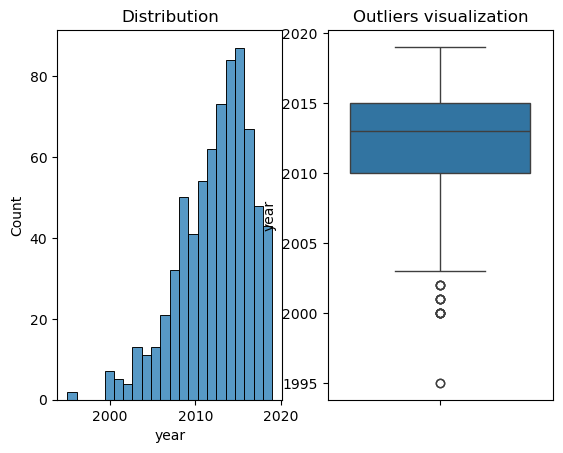

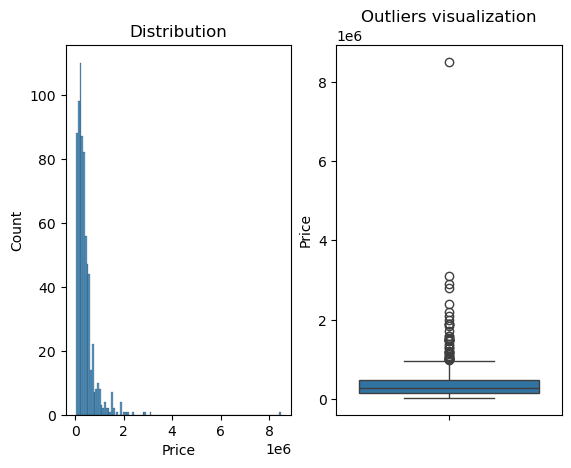

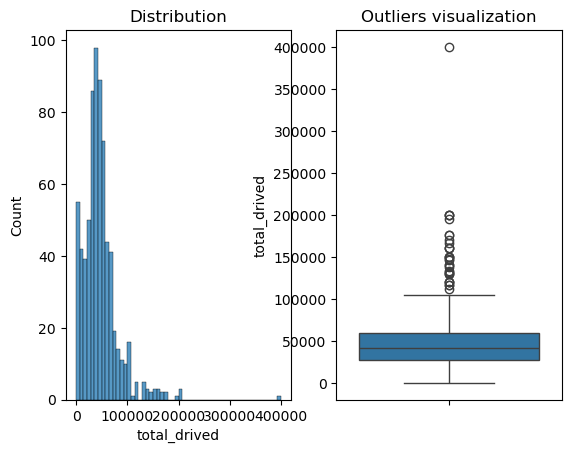

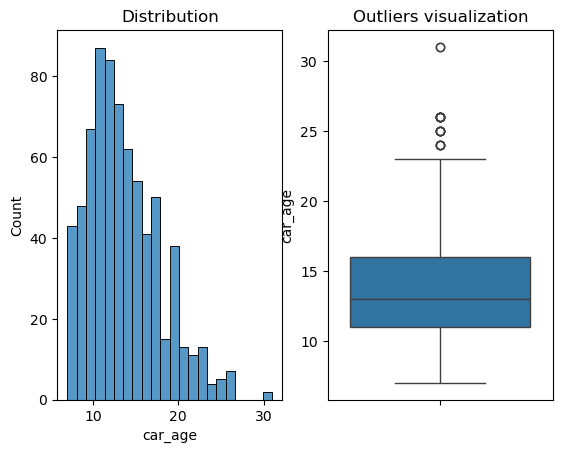

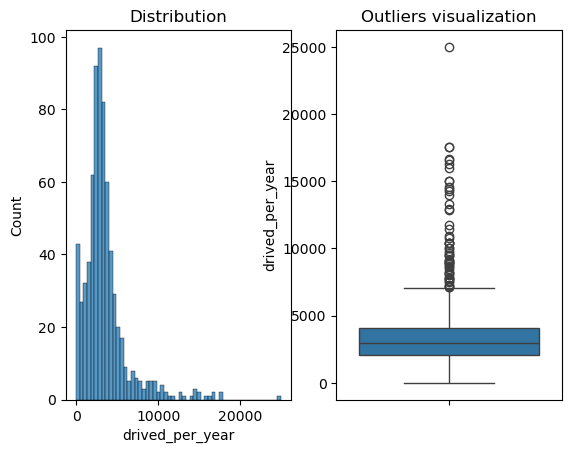

In [33]:
num_cols = df.select_dtypes(['int32', 'int64', 'float64']).columns
for i in num_cols:
    plt.subplot(1,2,1)
    sns.histplot(df[i])
    plt.title('Distribution')

    plt.subplot(1,2,2)
    sns.boxplot(df[i])
    plt.title('Outliers visualization')
    plt.show()

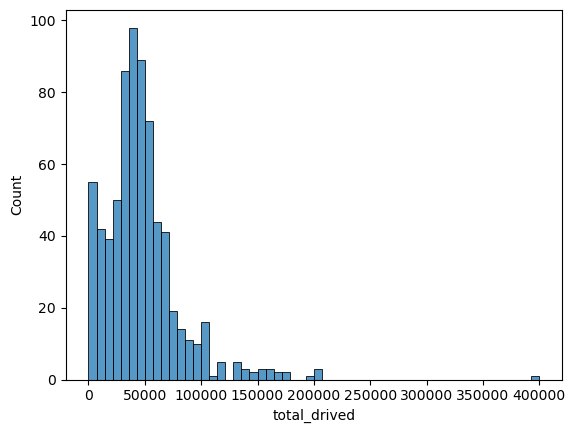

In [34]:
sns.histplot(df['total_drived'])
plt.show()

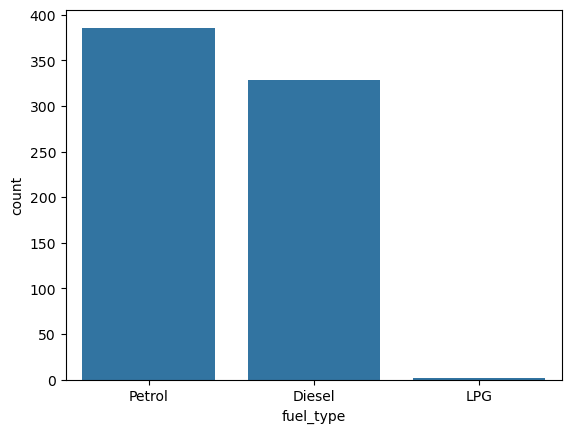

In [35]:
sns.countplot(x=df['fuel_type'])
plt.show()

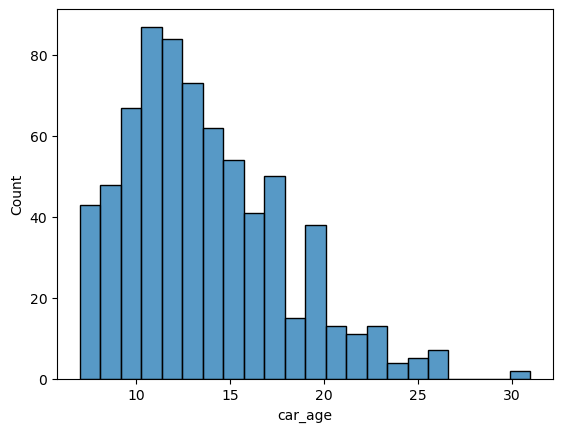

In [36]:
sns.histplot(df['car_age'])
plt.show()

## Outliers Handling

In [38]:
df['total_drived'] = df['total_drived'].astype(float)
df['drived_per_year'] = df['drived_per_year'].astype(float)

In [39]:
upper_td = df['total_drived'].quantile(0.99)
df.loc[df['total_drived'] > upper_td, 'total_drived'] = upper_td

upper_dpy = df['drived_per_year'].quantile(0.99)
df.loc[df['drived_per_year'] > upper_dpy, 'drived_per_year'] = upper_dpy

df['Price'] = np.log1p(df['Price'])

## Train Test Split

In [41]:
x = df.drop('Price', axis = 1)
y = df['Price']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state=42)

## Model Processing and Comparison

In [43]:
categorical_cols = ['company','fuel_type']
numeric_cols = ['total_drived','car_age','drived_per_year']

transformer = ColumnTransformer(
    transformers=[
        ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols),
        ('scale', StandardScaler(), numeric_cols)
    ],
    remainder='passthrough'
    ,force_int_remainder_cols=False
)


In [44]:
models = {
    "Linear Regression": Pipeline([
        ('transformer', transformer),
        ('lr', LinearRegression())
    ]),
    
    "Ridge Regression": Pipeline([
        ('transformer', transformer),
        ('ridge', Ridge(alpha=0.1))
    ]),
    
    "Decision Tree": Pipeline([
        ('transformer', transformer),
        ('dt', DecisionTreeRegressor(max_depth=5, random_state=42))
    ]),
    
    "Random Forest": Pipeline([
        ('transformer', transformer),
        ('rf', RandomForestRegressor(max_depth=5, n_estimators=200, random_state=42))
    ]),

    "Lasso": Pipeline([
        ('transformer', transformer),
        ('lasso', Lasso())
         ])
}

results = {}

for name, model in models.items():
    model.fit(x_train, y_train)
    results[name] = model.score(x_test, y_test)

comparison_df = pd.DataFrame(
    results.items(),
    columns=["Model", "Test R2 Score"]
)

comparison_df

,Model,Test R2 Score
0,Linear Regression,0.659532
1,Ridge Regression,0.652294
2,Decision Tree,0.373147
3,Random Forest,0.470717
4,Lasso,0.238025


## Ridge

In [46]:
model = Pipeline(steps=[
                  ('transformer', transformer),
                  ('ridge', Ridge())])

params_grid = {"ridge__alpha":[1,10,0.1]}

grid = GridSearchCV(model, params_grid, cv = 5)
grid.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('transformer',
                                        ColumnTransformer(force_int_remainder_cols=False,
                                                          remainder='passthrough',
                                                          transformers=[('ohe',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore'),
                                                                         ['company',
                                                                          'fuel_type']),
                                                                        ('scale',
                                                                         StandardScaler(),
                                                                         ['total_drived',
                                                                          'car_age',
                                                                          'drived_per_year'])])),
                                       ('ridge', Ridge())]),
             param_grid={'ridge__alpha': [1, 10, 0.1]})

In [47]:
best_model = grid.best_estimator_
best_model.fit(x_train, y_train)

Pipeline(steps=[('transformer',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('ohe',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['company', 'fuel_type']),
                                                 ('scale', StandardScaler(),
                                                  ['total_drived', 'car_age',
                                                   'drived_per_year'])])),
                ('ridge', Ridge(alpha=0.1))])

## Evaluation

In [49]:
# 1️⃣ Predict (log scale)
y_pred_log = best_model.predict(x_test)

# Convert back to real price
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

# R2 (log scale - model performance)
print("Train R2 (log scale):", best_model.score(x_train, y_train))
print("Test R2 (log scale):", best_model.score(x_test, y_test))

# 5️⃣ MAE (real price ₹)
print("MAE (Real Price):", mean_absolute_error(y_true, y_pred))


Train R2 (log scale): 0.7138997690646218
Test R2 (log scale): 0.652293875517677
MAE (Real Price): 207664.56525681043


## Cross Validation 

In [51]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(best_model, x, y, cv=5, scoring='r2')
print("CV Mean R2:", scores.mean())

CV Mean R2: 0.6424808574919801
